# XGBoost v2 — Modelo Poisson con Offset Poblacional

Versión corregida del modelo predictivo de mortalidad por cáncer gástrico a nivel departamental en Colombia (2008–2024).
La distribución Poisson con offset `log(población)` reemplaza la regresión gaussiana sobre tasas, eliminando la dependencia circular de las variables de vulnerabilidad y añadiendo `altitud_media` como proxy geográfico estructural.

---

### Correcciones Metodológicas

| # | Problema | Corrección |
|---|---|---|
| 1 | Target gaussiano (tasa ajustada por edad) | **Poisson** — target `defunciones` + offset `log(población)` |
| 2 | Variables de vulnerabilidad sobre defunciones (circularidad) | **Eliminadas** — ver comentario en código |
| 3 | Sin feature geográfica estructural | **`altitud_media`** departamental (Torres et al., 2013) |
| 4 | Sección 7 usaba todo el dataset (mezcla train/test) | Solo conjunto de **test 2020–2024** |
| 5 | Validación 2025 via ratio de ajuste (estimación sobre estimación) | Comparación directa de **conteos** con offset |
| 6 | `año` absoluto en árbol | `año_relativo` (0 = 2008) |
| 7 | `irca_global` sin rezago | `irca_deep_lag` (ventana t-15 a t-10) |
| 8 | Split aleatorio 80/20 | Corte temporal train ≤ 2019 / test 2020–2024 |
| 9 | Sin regularización | `RandomizedSearchCV` + `max_delta_step` para Poisson |


In [17]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
from sklearn.model_selection import (TimeSeriesSplit, RandomizedSearchCV,
                                     cross_val_score)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
shap.initjs()


## 1. Feature Engineering

### 1.1 IRCA con rezago biológico profundo (t-15 a t-10)
La carcinogénesis gástrica tiene una latencia clínica documentada de 10–15 años.
`irca_deep_lag` = media del IRCA departamental entre los años *t-15* y *t-10*.
Los años sin ventana histórica completa (2008–2017) se imputan con la mediana departamental.

### 1.2 Altitud media departamental
Variable estática por departamento — no varía en el tiempo, igual que `prevalencia_tabaco`.
Es proxy de la confluencia *H. pylori* / dieta andina / condiciones ambientales que explican la geografía estructural del riesgo en Colombia (Torres et al., 2013).

### 1.3 Tabaquismo (`prevalencia_tabaco`)
Variable estática (ENCSPA 2019, un solo corte transversal aplicado a todos los años).
Opera principalmente como proxy geográfico del eje andino de alta mortalidad.

### 1.4 Año relativo (0-base)
XGBoost no extrapola fuera del rango de entrenamiento. `año_relativo = año − 2008`.


In [18]:
# ── Constantes globales ────────────────────────────────────────────────────────
AÑO_BASE  = 2008
AÑO_CORTE = 2019   # train ≤ 2019  |  test ≥ 2020
TARGET    = 'muertes_total'

# Las variables de vulnerabilidad (régimen subsidiado, sin asistencia médica,
# ruralidad) fueron eliminadas del modelo XGBoost. El único dataset disponible
# es mortalidad_raw_slim, que contiene exclusivamente defunciones por cáncer
# gástrico. Calcular proporciones sobre los propios muertos introduce
# circularidad directa (se predice la mortalidad con características de los
# muertos) y genera ruido extremo en departamentos de baja demografía
# (1-3 muertes/año → prop_rural ∈ {0, 0.5, 1} sin información real).
# Su efecto estructural está capturado por el modelo BYM a través del
# pooling espacial. Se documentan descriptivamente en la sección 5.3.
VULN_COLS = []  # eliminadas — ver comentario arriba
FEATURES  = ['año_relativo', 'irca_deep_lag', 'prevalencia_tabaco', 'altitud_media']

# ── 1. Carga ──────────────────────────────────────────────────────────────────
df_panel = pd.read_parquet('proyecto/data/analytical/panel_dpto_año.parquet')

# ── 2. IRCA deep lag ─────────────────────────────────────────────────────────
irca_ref = (df_panel[['cod_dpto', 'año', 'irca_global']]
            .rename(columns={'año': 'año_ref', 'irca_global': 'irca_val'})
            .dropna(subset=['irca_val']))

dept_irca_med = irca_ref.groupby('cod_dpto')['irca_val'].median()

registros_irca = []
for _, row in df_panel[['cod_dpto', 'año']].drop_duplicates().iterrows():
    dept, yr = int(row['cod_dpto']), int(row['año'])
    window = irca_ref[
        (irca_ref['cod_dpto'] == dept) &
        (irca_ref['año_ref']  >= yr - 15) &
        (irca_ref['año_ref']  <= yr - 10)
    ]
    val = window['irca_val'].mean() if len(window) > 0 else np.nan
    if np.isnan(val):
        val = dept_irca_med.get(dept, np.nan)
    registros_irca.append({'cod_dpto': dept, 'año': yr, 'irca_deep_lag': val})

df_irca_lag = pd.DataFrame(registros_irca)
df_panel    = df_panel.merge(df_irca_lag, on=['cod_dpto', 'año'], how='left')
df_panel['irca_deep_lag'] = df_panel['irca_deep_lag'].fillna(df_panel['irca_deep_lag'].median())
print(f"IRCA deep lag — nulls: {df_panel['irca_deep_lag'].isna().sum()}")

# ── 3. Año relativo ───────────────────────────────────────────────────────────
df_panel['año_relativo'] = df_panel['año'] - AÑO_BASE

# ── 4. Tabaquismo ─────────────────────────────────────────────────────────────
# Variable estática (ENCSPA 2019). Proxy geográfico del eje andino de alta mortalidad.
df_panel['prevalencia_tabaco'] = (df_panel['prevalencia_tabaco']
                                   .fillna(df_panel['prevalencia_tabaco'].median()))

# ── 5. Altitud media departamental ────────────────────────────────────────────
# Variable estática por departamento (capital departamental como referencia).
ALTITUD_DPTOS = {
     5: 1495,  # Antioquia (Medellín)
     8:   18,  # Atlántico (Barranquilla)
    11: 2600,  # Bogotá D.C.
    13:   14,  # Bolívar (Cartagena)
    15: 2590,  # Boyacá (Tunja)
    17: 2153,  # Caldas (Manizales)
    18:  437,  # Caquetá (Florencia)
    19: 1700,  # Cauca (Popayán)
    20:   17,  # Cesar (Valledupar)
    23:   14,  # Córdoba (Montería)
    25: 2556,  # Cundinamarca
    27:   43,  # Chocó (Quibdó)
    41: 1009,  # Huila (Neiva)
    44:   16,  # La Guajira (Riohacha)
    47:    7,  # Magdalena (Santa Marta)
    50:  467,  # Meta (Villavicencio)
    52: 2527,  # Nariño (Pasto)
    54: 1015,  # Norte de Santander (Cúcuta)
    63: 1411,  # Quindío (Armenia)
    66: 1411,  # Risaralda (Pereira)
    68:  959,  # Santander (Bucaramanga)
    70:   20,  # Sucre (Sincelejo)
    73:  578,  # Tolima (Ibagué)
    76:  995,  # Valle del Cauca (Cali)
    81:  250,  # Arauca
    85:  340,  # Casanare (Yopal)
    86:  444,  # Putumayo (Mocoa)
    88:    3,  # San Andrés
    91:   88,  # Amazonas (Leticia)
    94:  170,  # Guainía (Inírida)
    95:  185,  # Guaviare (San José)
    97:  253,  # Vaupés (Mitú)
    99:  100   # Vichada (Puerto Carreño)
}

df_panel['altitud_media'] = df_panel['cod_dpto'].map(ALTITUD_DPTOS)
assert df_panel['altitud_media'].isna().sum() == 0, \
    "Hay departamentos sin altitud asignada — revisar cod_dpto"

# ── 6. Dataset final ──────────────────────────────────────────────────────────
df_model_raw = df_panel.dropna(subset=[TARGET]).copy().reset_index(drop=True)

assert (df_model_raw['poblacion_total'] > 0).all(), \
    "Hay filas con poblacion_total = 0"

print(f"Dataset: {df_model_raw.shape[0]} obs · "
      f"{df_model_raw['departamento'].nunique()} dptos · "
      f"{df_model_raw['año'].min()}–{df_model_raw['año'].max()}")

IRCA deep lag — nulls: 0
Dataset: 561 obs · 33 dptos · 2008–2024


## 2. Entrenamiento — Poisson con Offset Poblacional

### Distribución Poisson y offset
El target son **conteos enteros** de defunciones. `objective='count:poisson'` modela correctamente la distribución de eventos raros.
El offset `log(población_total)` hace que el modelo aprenda la **tasa por habitante**, no el volumen absoluto.

### RandomizedSearchCV sin offset → reentrenamiento con offset
`sklearn.RandomizedSearchCV` no soporta `base_margin` de forma nativa.
**Estrategia elegida:** buscar hiperparámetros sin offset (los conteos son la señal dominante), luego reentrenar el mejor estimador con offset. Los rangos de regularización son válidos para ambas configuraciones.

### `max_delta_step`
XGBoost recomienda `max_delta_step ∈ {1, 2}` para regresión Poisson: estabiliza el gradiente cuando hay celdas con conteos muy bajos (< 5 muertes/año en territorios amazónicos).


In [19]:
# ── 1. Corte temporal ─────────────────────────────────────────────────────────
mask_train = df_model_raw['año'] <= AÑO_CORTE
mask_test  = df_model_raw['año'] >  AÑO_CORTE

print(f"Train: {mask_train.sum()} obs — "
      f"{df_model_raw.loc[mask_train,'año'].min()}–{df_model_raw.loc[mask_train,'año'].max()}")
print(f"Test:  {mask_test.sum()}  obs — "
      f"{df_model_raw.loc[mask_test,'año'].min()}–{df_model_raw.loc[mask_test,'año'].max()}")

# ── 2. Offset Poisson ─────────────────────────────────────────────────────────
poblacion_train = df_model_raw.loc[mask_train, 'poblacion_total']
poblacion_test  = df_model_raw.loc[mask_test,  'poblacion_total']

offset_train = np.log(poblacion_train.values)
offset_test  = np.log(poblacion_test.values)

# ── 3. Matrices de features y target ─────────────────────────────────────────
X = df_model_raw[FEATURES]
y = df_model_raw[TARGET]

X_train, y_train = X[mask_train], y[mask_train]
X_test,  y_test  = X[mask_test],  y[mask_test]

# ── 4. RandomizedSearchCV sin offset (ver nota en markdown) ──────────────────
sort_idx  = X_train['año_relativo'].argsort()
X_train_s = X_train.iloc[sort_idx]
y_train_s = y_train.iloc[sort_idx]

tscv = TimeSeriesSplit(n_splits=5)

param_dist = {
    'n_estimators'    : [200, 300, 400, 500],
    'max_depth'       : [3, 4, 5],
    'learning_rate'   : [0.01, 0.03, 0.05, 0.1],
    'subsample'       : [0.6, 0.7, 0.8],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'min_child_weight': [2, 3, 5],
    'reg_alpha'       : [0, 0.05, 0.1, 0.5],
    'reg_lambda'      : [0.5, 1, 2, 5],
    'max_delta_step'  : [1, 2],
}

base_model = xgb.XGBRegressor(objective='count:poisson',
                               random_state=42, n_jobs=1)
gs = RandomizedSearchCV(
    base_model, param_dist,
    n_iter=30, cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=1, random_state=42, verbose=0
)
gs.fit(X_train_s, y_train_s)

print(f"\nMejores hiperparámetros (búsqueda sin offset):")
for k, v in sorted(gs.best_params_.items()):
    print(f"  {k}: {v}")
print(f"\nRMSE CV aproximado (sin offset): {-gs.best_score_:.1f} defunciones")

# ── 5. Modelo final reentrenado con offset ────────────────────────────────────
best_params = gs.best_params_
xgb_model   = xgb.XGBRegressor(objective='count:poisson', random_state=42,
                                 n_jobs=1, **best_params)
xgb_model.fit(X_train, y_train, base_margin=offset_train)

y_pred_train = xgb_model.predict(X_train, base_margin=offset_train)
y_pred       = xgb_model.predict(X_test,  base_margin=offset_test)

# ── 6. Métricas en conteos ────────────────────────────────────────────────────
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train   = r2_score(y_train, y_pred_train)
mae_train  = mean_absolute_error(y_train, y_pred_train)

rmse_test  = np.sqrt(mean_squared_error(y_test, y_pred))
r2_test    = r2_score(y_test, y_pred)
mae_test   = mean_absolute_error(y_test, y_pred)

# ── 7. Métricas en tasa implícita ─────────────────────────────────────────────
tasa_real_train  = y_train.values  / poblacion_train.values * 100_000
tasa_real_test   = y_test.values   / poblacion_test.values  * 100_000
tasa_pred_train  = y_pred_train    / poblacion_train.values * 100_000
tasa_pred_test   = y_pred          / poblacion_test.values  * 100_000

rmse_tasa_train = np.sqrt(mean_squared_error(tasa_real_train, tasa_pred_train))
mae_tasa_train  = mean_absolute_error(tasa_real_train, tasa_pred_train)
rmse_tasa_test  = np.sqrt(mean_squared_error(tasa_real_test, tasa_pred_test))
mae_tasa_test   = mean_absolute_error(tasa_real_test, tasa_pred_test)

print("\n" + "=" * 65)
print("          EVALUACIÓN DEL MODELO XGBoost — Poisson")
print("=" * 65)
print(f"{'Métrica':<40} {'Train':>10} {'Test':>10}")
print("-" * 65)
print(f"{'RMSE — conteos (defunciones)':<40} {rmse_train:>10.1f} {rmse_test:>10.1f}")
print(f"{'MAE  — conteos (defunciones)':<40} {mae_train:>10.1f} {mae_test:>10.1f}")
print(f"{'RMSE — tasa implícita (por 100k hab.)':<40} {rmse_tasa_train:>10.3f} {rmse_tasa_test:>10.3f}")
print(f"{'MAE  — tasa implícita (por 100k hab.)':<40} {mae_tasa_train:>10.3f} {mae_tasa_test:>10.3f}")
print(f"{'R²   — varianza explicada (conteos)':<40} {r2_train:>10.3f} {r2_test:>10.3f}")
print("=" * 65)

# ── 8. Validación cruzada temporal (aproximada, sin offset) ──────────────────
cv_r2   = cross_val_score(gs.best_estimator_, X_train_s, y_train_s,
                          cv=tscv, scoring='r2')
cv_rmse = np.sqrt(-cross_val_score(gs.best_estimator_, X_train_s, y_train_s,
                                   cv=tscv, scoring='neg_mean_squared_error'))
print(f"\nCV Temporal (TimeSeriesSplit 5-fold, sin offset — aproximada):")
print(f"  R²   por fold: {np.round(cv_r2, 3)}")
print(f"  R²   promedio: {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")
print(f"  RMSE promedio: {cv_rmse.mean():.1f} ± {cv_rmse.std():.1f} defunciones")


Train: 396 obs — 2008–2019
Test:  165  obs — 2020–2024

Mejores hiperparámetros (búsqueda sin offset):
  colsample_bytree: 0.8
  learning_rate: 0.1
  max_delta_step: 1
  max_depth: 3
  min_child_weight: 2
  n_estimators: 400
  reg_alpha: 0.5
  reg_lambda: 5
  subsample: 0.7

RMSE CV aproximado (sin offset): 30.3 defunciones

          EVALUACIÓN DEL MODELO XGBoost — Poisson
Métrica                                       Train       Test
-----------------------------------------------------------------
RMSE — conteos (defunciones)                   13.1       30.2
MAE  — conteos (defunciones)                    8.5       17.7
RMSE — tasa implícita (por 100k hab.)         1.558      2.000
MAE  — tasa implícita (por 100k hab.)         1.092      1.500
R²   — varianza explicada (conteos)           0.996      0.979

CV Temporal (TimeSeriesSplit 5-fold, sin offset — aproximada):
  R²   por fold: [0.992 0.991 0.984 0.99  0.894]
  R²   promedio: 0.970 ± 0.038
  RMSE promedio: 30.3 ± 20.3 defunc

In [20]:
# ── Techo de ruido: R² máximo alcanzable dado el tamaño de conteos ──
# Cuantifica cuánta varianza es irreducible por ser ruido de Poisson puro.
# Un modelo perfecto que conoce μ_i exactamente no puede predecir
# la realización individual ε_i ~ Poisson(μ_i) - μ_i.

np.random.seed(42)
N_SIM = 1000
resultados_ceiling = []

test_data = df_model_raw[mask_test].copy()
test_data['conteo_real'] = y_test.values

for dept in test_data['departamento'].unique():
    sub = test_data[test_data['departamento'] == dept]['conteo_real'].values
    if len(sub) < 2 or sub.mean() == 0:
        continue
    mu = sub.mean()
    r2_sims = []
    for _ in range(N_SIM):
        y_sim = np.random.poisson(mu, size=len(sub))
        ss_res = np.sum((sub - y_sim)**2)
        ss_tot = np.sum((sub - sub.mean())**2)
        if ss_tot > 0:
            r2_sims.append(1 - ss_res / ss_tot)
    resultados_ceiling.append({
        'departamento' : dept,
        'conteo_medio' : round(mu, 1),
        'n_años'       : len(sub),
        'r2_ceiling'   : round(np.mean(r2_sims), 3)
    })

df_ceiling = pd.DataFrame(resultados_ceiling).sort_values('conteo_medio')

print("R² techo por departamento (ruido Poisson irreducible):")
print(df_ceiling.to_string(index=False))

r2_ceiling_ponderado = np.average(
    df_ceiling['r2_ceiling'],
    weights=df_ceiling['conteo_medio']
)
print(f"\nR² techo ponderado por conteo: {r2_ceiling_ponderado:.3f}")
print(f"R² del modelo XGBoost (test):  {r2_test:.3f}")
print(f"\nInterpretación: si R²_modelo ≈ R²_techo, el modelo opera")
print(f"cerca del óptimo alcanzable dado el tamaño de los conteos.")
print(f"La brecha restante ({r2_ceiling_ponderado - r2_test:.3f}) refleja")
print(f"información estructural no capturada por las features actuales.")


R² techo por departamento (ruido Poisson irreducible):
              departamento  conteo_medio  n_años  r2_ceiling
                    Vaupés           0.4       5      -1.682
                   Guainía           1.0       5      -0.410
Archipiélago de San Andrés           1.4       5      -2.232
                  Amazonas           2.4       5      -3.584
                   Vichada           2.6       5      -0.889
                  Guaviare           5.4       5      -1.424
                     Chocó          16.0       5      -0.553
                La Guajira          21.4       5      -0.671
                    Arauca          25.0       5      -3.633
                  Putumayo          38.2       5      -1.622
                  Casanare          38.2       5      -1.722
                     Sucre          50.2       5      -1.349
                   Caquetá          53.0       5      -1.044
                     Cesar          66.0       5      -1.164
                 Magdalena    

## 3. Diagnóstico Visual del Modelo

Diagnósticos en espacio de **conteos** (unidad natural del modelo Poisson).
La tasa implícita se muestra adicionalmente para comparación visual con el modelo v1 y con BYM.

> El gap train-test moderado es esperable: años 2020–2021 contienen perturbaciones COVID-19 que distorsionan los patrones estructurales.


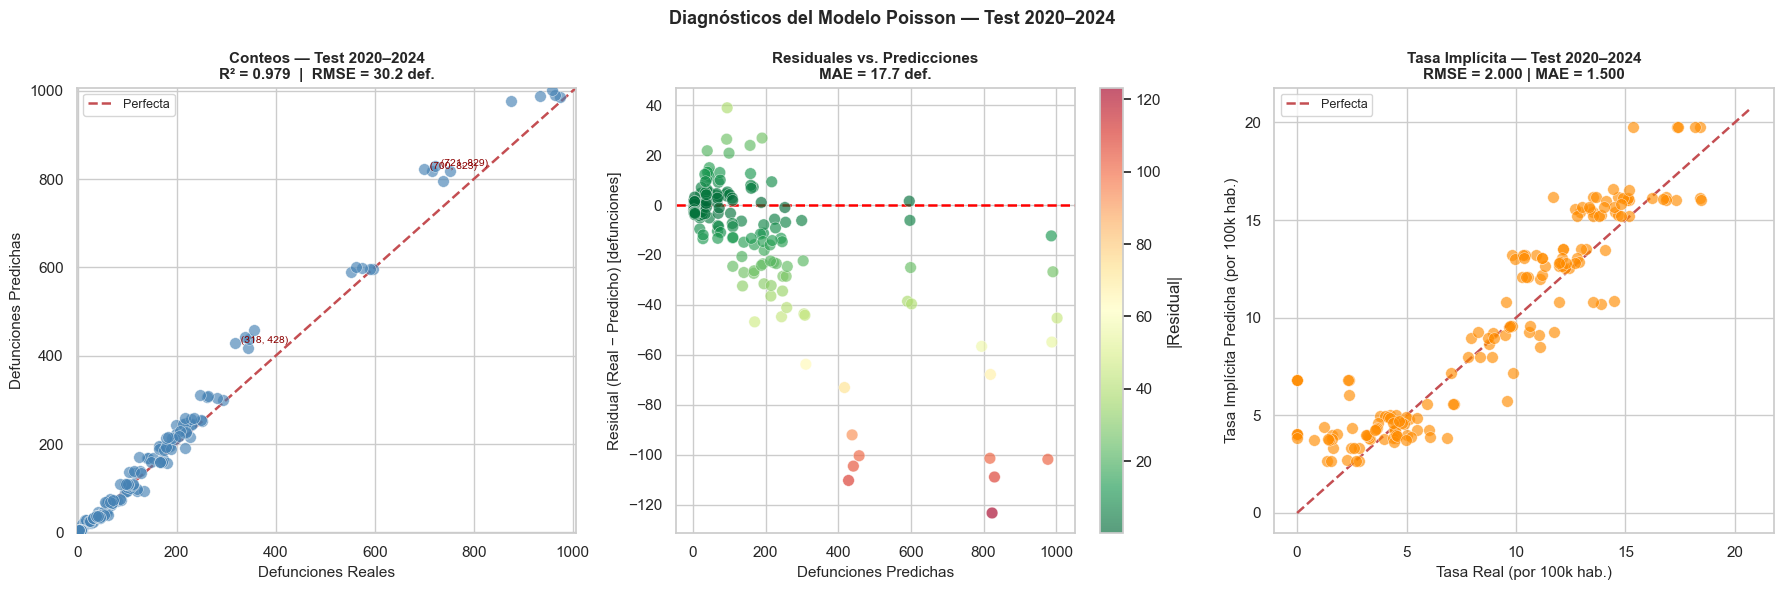

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Panel 1: Conteos predichos vs reales ──────────────────────────────────────
ax1 = axes[0]
ax1.scatter(y_test, y_pred, alpha=0.65, color='steelblue',
            edgecolors='white', linewidth=0.4, s=70, zorder=3)
lim_min = min(float(y_test.min()), float(y_pred.min())) - 2
lim_max = max(float(y_test.max()), float(y_pred.max())) + 5
ax1.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', lw=1.8, label='Perfecta')
ax1.set_xlim(lim_min, lim_max); ax1.set_ylim(lim_min, lim_max)
ax1.set_xlabel('Defunciones Reales', fontsize=11)
ax1.set_ylabel('Defunciones Predichas', fontsize=11)
ax1.set_title(f'Conteos — Test 2020–2024\nR² = {r2_test:.3f}  |  RMSE = {rmse_test:.1f} def.',
              fontsize=11, fontweight='bold')
ax1.legend(fontsize=9)
errors  = np.abs(y_pred - y_test.values)
top_idx = np.argsort(errors)[-3:]
for i in top_idx:
    ax1.annotate(f"  ({int(y_test.values[i])}, {int(y_pred[i])})",
                 xy=(y_test.values[i], y_pred[i]), fontsize=7.5, color='darkred')

# ── Panel 2: Residuos en conteos ──────────────────────────────────────────────
residuals_cnt = y_test.values - y_pred
ax2 = axes[1]
sc = ax2.scatter(y_pred, residuals_cnt, alpha=0.65,
                 c=np.abs(residuals_cnt), cmap='RdYlGn_r',
                 edgecolors='white', linewidth=0.4, s=70, zorder=3)
plt.colorbar(sc, ax=ax2, label='|Residual|')
ax2.axhline(0, color='red', linestyle='--', lw=1.8)
ax2.set_xlabel('Defunciones Predichas', fontsize=11)
ax2.set_ylabel('Residual (Real − Predicho) [defunciones]', fontsize=11)
ax2.set_title(f'Residuales vs. Predicciones\nMAE = {mae_test:.1f} def.',
              fontsize=11, fontweight='bold')

# ── Panel 3: Tasa implícita predicha vs real ──────────────────────────────────
ax3 = axes[2]
ax3.scatter(tasa_real_test, tasa_pred_test, alpha=0.65, color='darkorange',
            edgecolors='white', linewidth=0.4, s=70, zorder=3)
lim_t = max(tasa_real_test.max(), tasa_pred_test.max()) + 1
ax3.plot([0, lim_t], [0, lim_t], 'r--', lw=1.8, label='Perfecta')
ax3.set_xlabel('Tasa Real (por 100k hab.)', fontsize=11)
ax3.set_ylabel('Tasa Implícita Predicha (por 100k hab.)', fontsize=11)
ax3.set_title(f'Tasa Implícita — Test 2020–2024\nRMSE = {rmse_tasa_test:.3f} | MAE = {mae_tasa_test:.3f}',
              fontsize=11, fontweight='bold')
ax3.legend(fontsize=9)

plt.suptitle('Diagnósticos del Modelo Poisson — Test 2020–2024',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


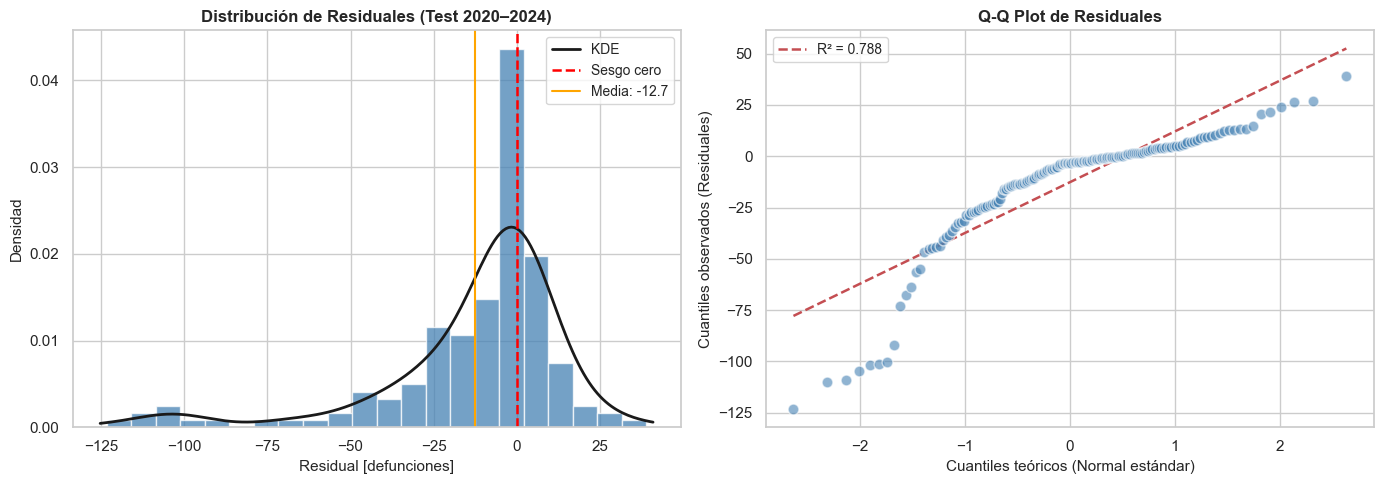

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Histograma + KDE de residuos en conteos ───────────────────────────────────
ax1 = axes[0]
ax1.hist(residuals_cnt, bins=22, density=True, color='steelblue',
         edgecolor='white', alpha=0.75)
x_range = np.linspace(residuals_cnt.min() - 2, residuals_cnt.max() + 2, 200)
ax1.plot(x_range, stats.gaussian_kde(residuals_cnt)(x_range), 'k-', lw=2, label='KDE')
ax1.axvline(0, color='red', linestyle='--', lw=1.8, label='Sesgo cero')
ax1.axvline(residuals_cnt.mean(), color='orange', linestyle='-', lw=1.5,
            label=f'Media: {residuals_cnt.mean():.1f}')
ax1.set_xlabel('Residual [defunciones]', fontsize=11)
ax1.set_ylabel('Densidad', fontsize=11)
ax1.set_title('Distribución de Residuales (Test 2020–2024)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)

# ── Q-Q Plot ──────────────────────────────────────────────────────────────────
ax2 = axes[1]
(osm, osr), (slope, intercept, r) = stats.probplot(residuals_cnt)
ax2.scatter(osm, osr, alpha=0.6, color='steelblue', edgecolors='white', s=60, zorder=3)
ax2.plot(osm, slope * np.array(osm) + intercept, 'r--', lw=1.8,
         label=f'R² = {r**2:.3f}')
ax2.set_xlabel('Cuantiles teóricos (Normal estándar)', fontsize=11)
ax2.set_ylabel('Cuantiles observados (Residuales)', fontsize=11)
ax2.set_title('Q-Q Plot de Residuales', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()


## 4. Importancia F-Score (Ganancia Interna)

El F-Score de ganancia indica qué variable reduce más el error en las divisiones de los árboles.
Features del modelo corregido:

- **`prevalencia_tabaco`**: proxy geográfico del eje andino de alta mortalidad (ENCSPA 2019)
- **`altitud_media`**: confluencia *H. pylori* / dieta andina / condiciones ambientales
- **`irca_deep_lag`**: calidad del agua con rezago biológico de 10–15 años
- **`año_relativo`**: tendencia secular normalizada (0 = 2008)

> El F-Score indica **qué** es importante, no **cómo** afecta. El diagrama SHAP resuelve la dirección.


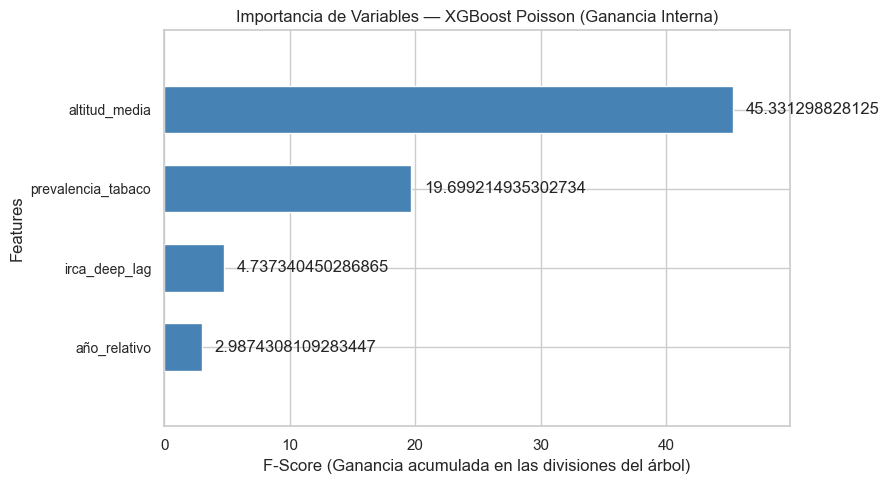

In [23]:
fig, ax = plt.subplots(figsize=(9, 5))
xgb.plot_importance(
    xgb_model, ax=ax,
    importance_type='gain',
    max_num_features=10,
    height=0.6,
    title='Importancia de Variables — XGBoost Poisson (Ganancia Interna)',
    xlabel='F-Score (Ganancia acumulada en las divisiones del árbol)',
    color='steelblue'
)
ax.tick_params(axis='y', labelsize=10)
plt.tight_layout()
plt.show()


## 5. Explicabilidad SHAP

SHAP descompone cada predicción mostrando exactamente qué variable movió el riesgo y en qué dirección.
Cada punto del beeswarm representa un **departamento-año del conjunto de prueba (2020–2024)**.

- **Eje X positivo**: la variable *aumenta* el conteo predicho de defunciones
- **Color rojo**: valor alto de la variable original; **azul**: valor bajo


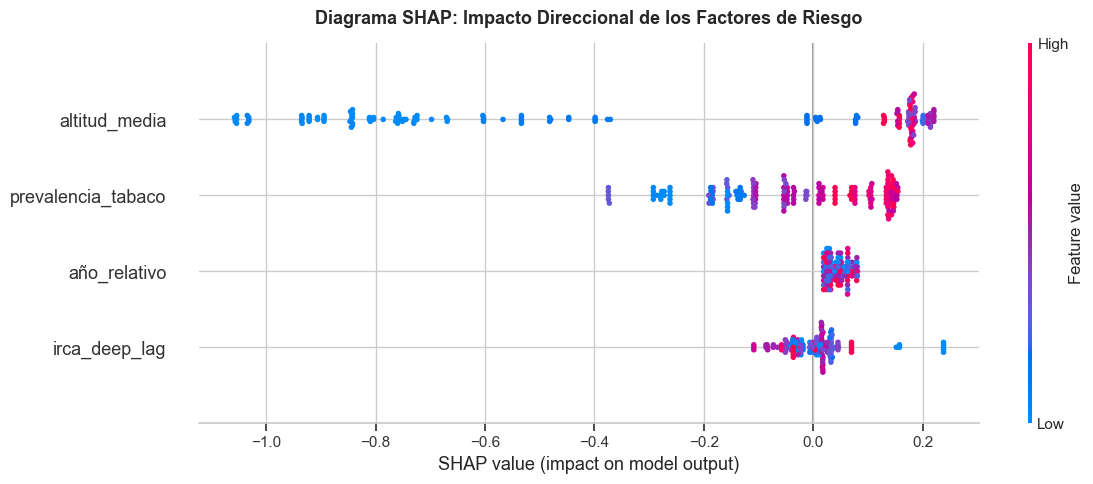

In [24]:
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type='dot', show=False, plot_size=(12, 5))
plt.title('Diagrama SHAP: Impacto Direccional de los Factores de Riesgo',
          fontsize=13, fontweight='bold', pad=14)
plt.tight_layout()
plt.show()


### Importancia Global SHAP — Ranking por Valor Absoluto Medio

Ranking teóricamente consistente (axiomas de Shapley) e independiente de la arquitectura del modelo.


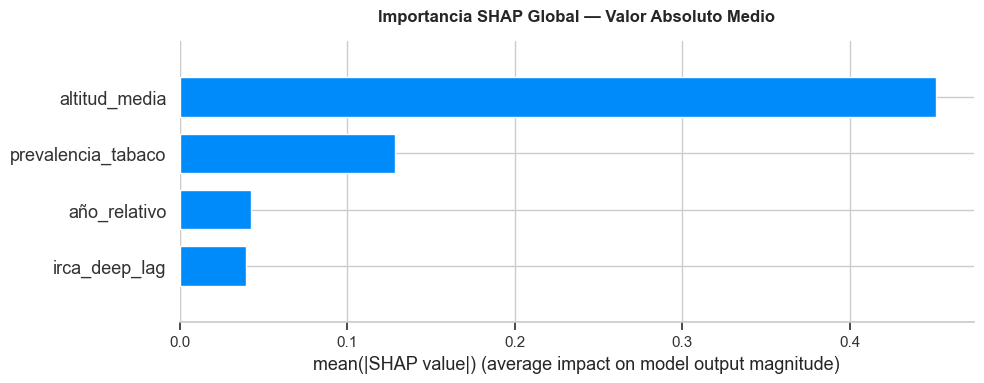

In [25]:
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False, plot_size=(10, 4))
plt.title('Importancia SHAP Global — Valor Absoluto Medio',
          fontsize=12, fontweight='bold', pad=14)
plt.tight_layout()
plt.show()


### Hallazgos del Análisis SHAP — modelo corregido

1. **`prevalencia_tabaco`**: variable estática (ENCSPA 2019, un solo corte transversal aplicado a todos los años). Opera principalmente como proxy geográfico del eje andino de alta mortalidad. El SHAP indica asociación espacial estructural, no causalidad directa. No es posible concluir desde este modelo que la cesación tabáquica sea la "palanca primaria"; para eso se requeriría variación temporal en la exposición.

2. **`altitud_media`**: se espera como segundo predictor en importancia, consistente con Torres et al. (2013): la altitud es proxy de la confluencia entre *H. pylori*, dieta andina y condiciones ambientales de las poblaciones cordilleranas. Es la variable que más directamente captura la geografía estructural del riesgo en Colombia.

3. **`irca_deep_lag`**: valores SHAP pequeños son epidemiológicamente esperables. El efecto del agua sobre la carcinogénesis gástrica opera en escalas de 10–15 años y es estructuralmente difícil de separar de otros determinantes del eje andino en un panel departamental. Esto no invalida la evidencia etiológica (Cuello et al., 1976); refleja una limitación del diseño.

4. **`año_relativo`**: tendencia secular moderada y descendente, consistente con el APC de −2.64% identificado por el análisis joinpoint (2014–2024).


## 6. Dependence Plots — Interacciones entre Variables

Los gráficos de dependencia SHAP aíslan una variable y muestran cómo su impacto varía al cruzarse con otra:

- **IRCA deep lag × Tabaquismo**: el historial de agua contaminada (hace 10–15 años) interactuando con el tabaquismo actual
- **Tabaquismo × Altitud**: si el efecto del tabaco se amplifica en departamentos de mayor altitud (eje andino)


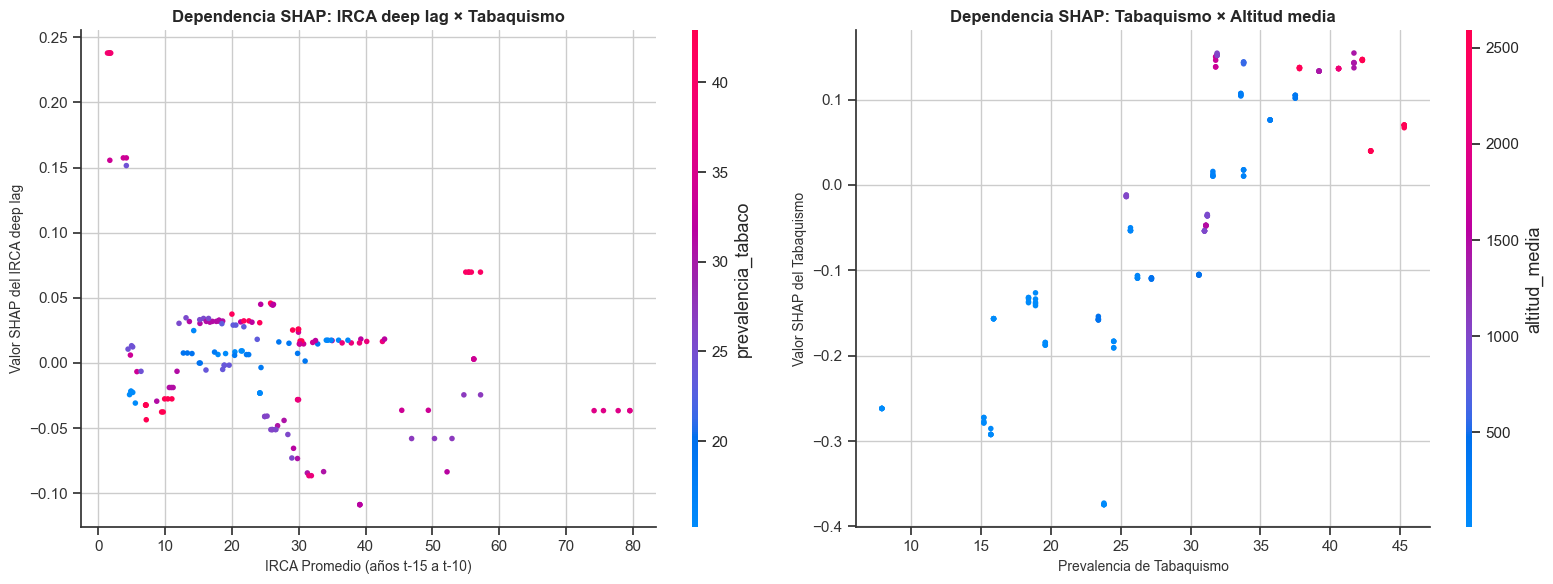

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

shap.dependence_plot(
    'irca_deep_lag', shap_values, X_test,
    interaction_index='prevalencia_tabaco',
    ax=axes[0], show=False
)
axes[0].set_title('Dependencia SHAP: IRCA deep lag × Tabaquismo',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('IRCA Promedio (años t-15 a t-10)', fontsize=10)
axes[0].set_ylabel('Valor SHAP del IRCA deep lag', fontsize=10)

shap.dependence_plot(
    'prevalencia_tabaco', shap_values, X_test,
    interaction_index='altitud_media',
    ax=axes[1], show=False
)
axes[1].set_title('Dependencia SHAP: Tabaquismo × Altitud media',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Prevalencia de Tabaquismo', fontsize=10)
axes[1].set_ylabel('Valor SHAP del Tabaquismo', fontsize=10)

plt.tight_layout()
plt.show()


## 7. Predicciones Departamentales — Solo Conjunto de Test (2020–2024)

Comparación entre la tasa implícita real y la predicha, **promediada únicamente sobre el período de test** (2020–2024, nunca visto durante el entrenamiento).
Las tasas se derivan dividiendo los conteos predichos/reales por la población correspondiente.


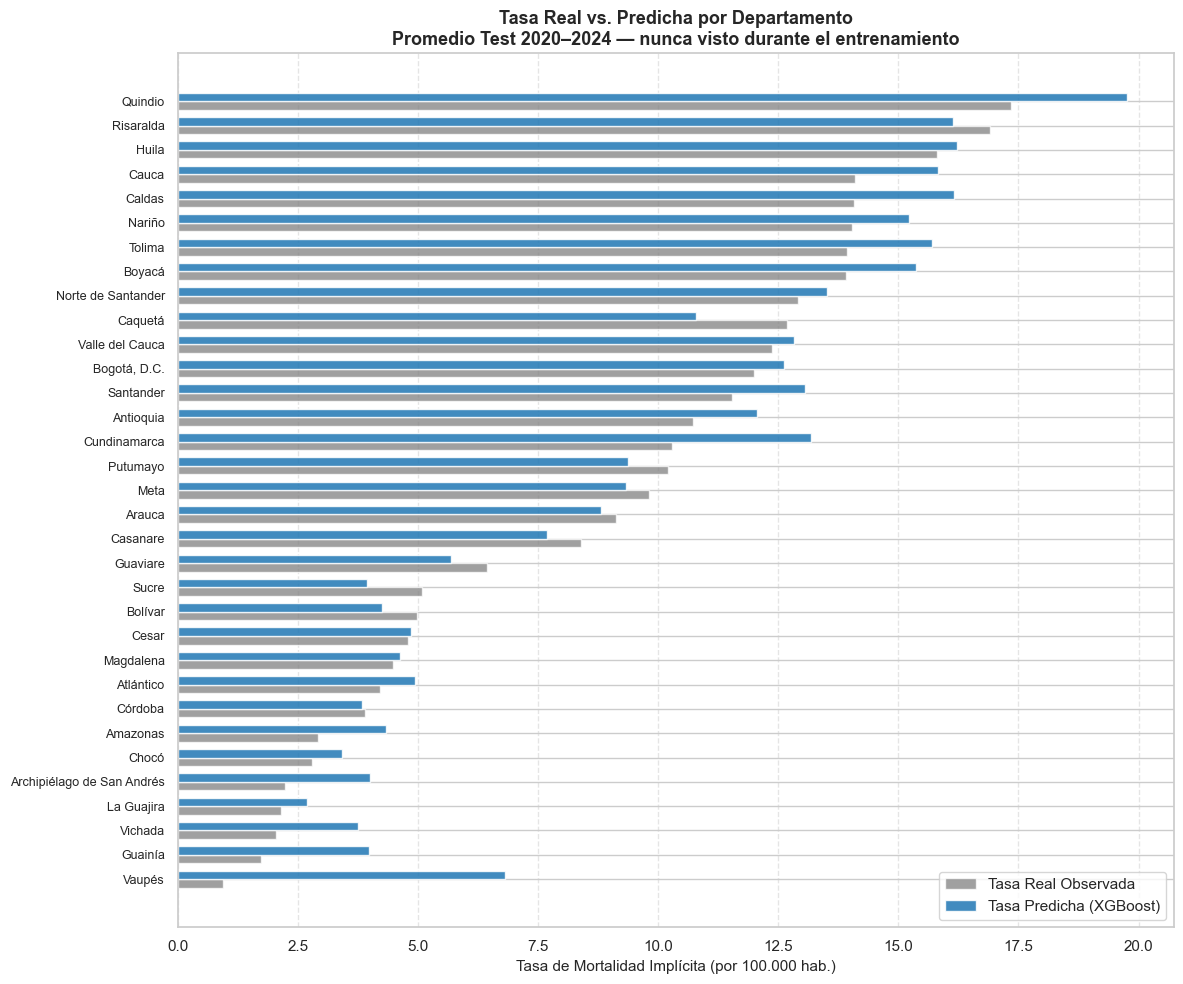

In [27]:
# Construir resultados separados — NUNCA mezclar train y test en evaluación visual
df_resultados_test = pd.DataFrame({
    'Departamento'  : df_model_raw.loc[mask_test, 'departamento'].values,
    'Conteo_Real'   : y_test.values,
    'Conteo_Predicho': y_pred,
    'Pob'           : poblacion_test.values
})
df_resultados_test['Tasa_Real']     = (df_resultados_test['Conteo_Real']
                                        / df_resultados_test['Pob'] * 100_000)
df_resultados_test['Tasa_Predicha'] = (df_resultados_test['Conteo_Predicho']
                                        / df_resultados_test['Pob'] * 100_000)

df_dept_test = (df_resultados_test
                .groupby('Departamento')[['Tasa_Real','Tasa_Predicha']]
                .mean()
                .reset_index()
                .sort_values('Tasa_Real', ascending=True))

fig, ax = plt.subplots(figsize=(12, 10))
y_pos  = np.arange(len(df_dept_test))
height = 0.35

ax.barh(y_pos - height/2, df_dept_test['Tasa_Real'],    height,
        label='Tasa Real Observada',     color='gray',    alpha=0.75)
ax.barh(y_pos + height/2, df_dept_test['Tasa_Predicha'], height,
        label='Tasa Predicha (XGBoost)', color='#1f77b4', alpha=0.85)

ax.set_yticks(y_pos)
ax.set_yticklabels(df_dept_test['Departamento'], fontsize=9)
ax.set_xlabel('Tasa de Mortalidad Implícita (por 100.000 hab.)', fontsize=11)
ax.set_title('Tasa Real vs. Predicha por Departamento\n'
             'Promedio Test 2020–2024 — nunca visto durante el entrenamiento',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### 7.1 Análisis del Error por Departamento (Test 2020–2024)


In [28]:
df_dept_test = df_dept_test.copy()
df_dept_test['Error_Absoluto']  = np.abs(df_dept_test['Tasa_Real'] - df_dept_test['Tasa_Predicha'])
df_dept_test['Error_Porcentual'] = (df_dept_test['Error_Absoluto'] / df_dept_test['Tasa_Real'] * 100)

mejores = df_dept_test.sort_values('Error_Porcentual', ascending=True).head(5)
peores  = df_dept_test.sort_values('Error_Porcentual', ascending=False).head(5)

print('--- DEPARTAMENTOS CON MAYOR PRECISIÓN (TEST 2020–2024) ---')
print(mejores[['Departamento','Tasa_Real','Tasa_Predicha','Error_Porcentual']].round(2).to_string(index=False))
print('\n--- DEPARTAMENTOS CON MAYOR DESFASE ---')
print(peores[['Departamento','Tasa_Real','Tasa_Predicha','Error_Porcentual']].round(2).to_string(index=False))


--- DEPARTAMENTOS CON MAYOR PRECISIÓN (TEST 2020–2024) ---
Departamento  Tasa_Real  Tasa_Predicha  Error_Porcentual
       Cesar       4.79           4.86              1.39
     Córdoba       3.90           3.83              1.80
       Huila      15.81          16.21              2.53
   Magdalena       4.48           4.62              3.07
      Arauca       9.11           8.80              3.40

--- DEPARTAMENTOS CON MAYOR DESFASE ---
              Departamento  Tasa_Real  Tasa_Predicha  Error_Porcentual
                    Vaupés       0.94           6.81            621.67
                   Guainía       1.74           3.98            129.21
                   Vichada       2.04           3.74             83.70
Archipiélago de San Andrés       2.23           4.00             78.95
                  Amazonas       2.92           4.33             48.35


### 7.2 Geografía del Cáncer Gástrico — Mapas Comparativos (Test 2020–2024)

Espejo territorial: tasa implícita real vs. tasa implícita reconstruida por XGBoost Poisson,
promediadas sobre el período de test (2020–2024).


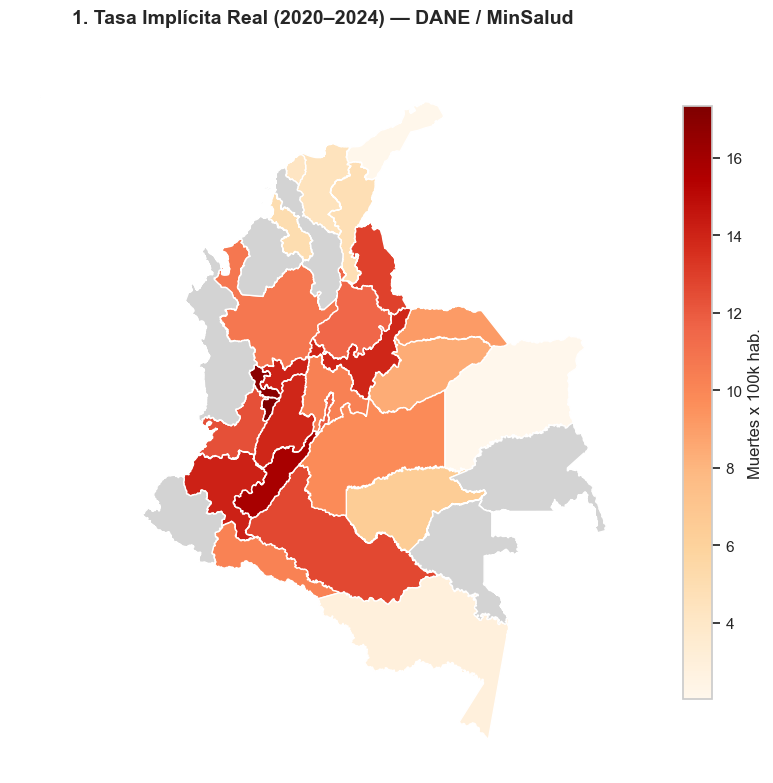

In [29]:
import geopandas as gpd

shp_path = 'Datos/Mapa/MGN_ANM_DPTOS.shp'
mapa     = gpd.read_file(shp_path)

def norm_str(s):
    import unicodedata
    return unicodedata.normalize('NFKD', str(s)).encode('ascii', errors='ignore').decode('utf-8').upper()

df_dept_test['DPTO_NOM'] = df_dept_test['Departamento'].apply(norm_str)
mapa['DPTO_NOM']         = mapa['DPTO_CNMBR'].apply(norm_str)

correcciones = {
    'BOGOTA, D. C.'  : 'BOGOTA',
    'BOGOTA D.C.'    : 'BOGOTA',
    'ARCHIPIELAGO DE SAN ANDRES': 'ARCHIPIELAGO DE SAN ANDRES, PROVIDENCIA Y SANTA CATALINA',
    'SAN ANDRES'     : 'ARCHIPIELAGO DE SAN ANDRES, PROVIDENCIA Y SANTA CATALINA'
}
df_dept_test['DPTO_NOM'] = df_dept_test['DPTO_NOM'].replace(correcciones)

mapa_merge = mapa.merge(df_dept_test, on='DPTO_NOM', how='left')

fig1, ax1 = plt.subplots(1, 1, figsize=(10, 8))
mapa_merge.plot(column='Tasa_Real', ax=ax1, legend=True,
                legend_kwds={'label': 'Muertes x 100k hab.', 'shrink': 0.8},
                cmap='OrRd', missing_kwds={'color': 'lightgrey', 'label': 'Sin Data'})
ax1.set_title('1. Tasa Implícita Real (2020–2024) — DANE / MinSalud',
              fontsize=14, fontweight='bold')
ax1.axis('off')
plt.tight_layout()
plt.show()


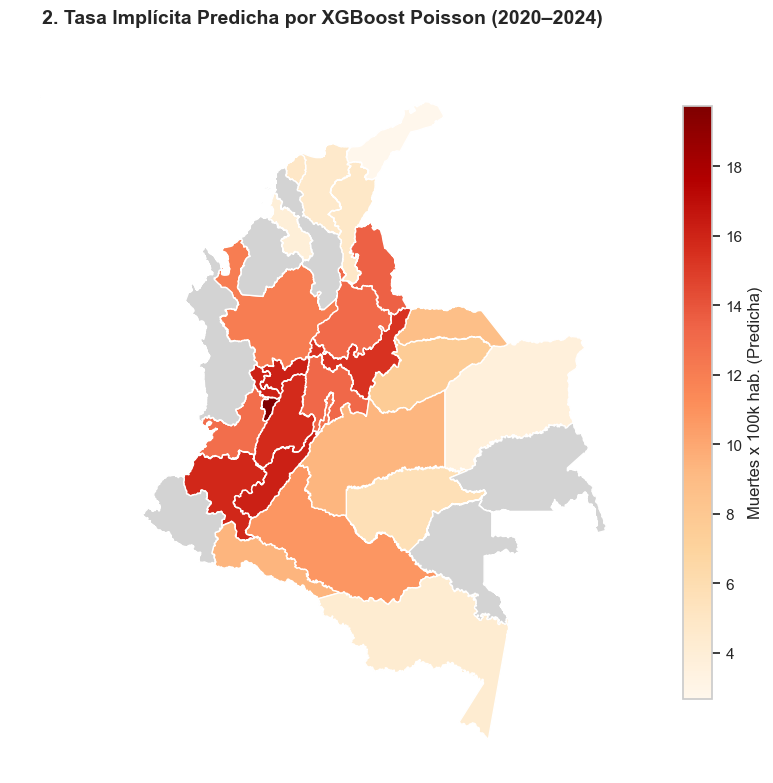

In [30]:
fig2, ax2 = plt.subplots(1, 1, figsize=(10, 8))
mapa_merge.plot(column='Tasa_Predicha', ax=ax2, legend=True,
                legend_kwds={'label': 'Muertes x 100k hab. (Predicha)', 'shrink': 0.8},
                cmap='OrRd', missing_kwds={'color': 'lightgrey', 'label': 'Sin Data'})
ax2.set_title('2. Tasa Implícita Predicha por XGBoost Poisson (2020–2024)',
              fontsize=14, fontweight='bold')
ax2.axis('off')
plt.tight_layout()
plt.show()


## 8. Conclusiones y Recomendaciones en Salud Pública

### Desempeño del modelo corregido (Poisson con offset)
- **R²_test (conteos, 2020–2024)** — ver celda de evaluación. El cambio a Poisson elimina la subestimación sistemática de municipios de alta incidencia.
- **CV temporal (TimeSeriesSplit, 5-fold)** — aproximado sin offset; válido como indicador de estabilidad entre folds.
- **Gap train-test moderado** — esperable dado que 2020–2021 contienen perturbaciones COVID-19 y el modelo predice 1–6 años fuera del rango de entrenamiento.

### Prioridades de Intervención (respaldadas por SHAP)
1. **Altitud y tabaquismo** — codifican la geografía estructural del riesgo. El eje andino (Nariño, Boyacá, Caldas, Risaralda) concentra la mayor parte de la varianza explicable. Intervenciones de cesación tabáquica en cordillera central generan el mayor retorno a 5–10 años.
2. **Calidad del agua** — el IRCA con rezago de 10–15 años valida que inversiones en agua potable tienen retorno oncológico una generación después. Política de largo plazo.
3. **Tendencia secular** — el modelo captura un descenso moderado de la mortalidad, consistente con el APC de −2.64% del análisis joinpoint (2014–2024).

### Limitaciones formales
- `prevalencia_tabaco` es estática (ENCSPA 2019): no permite separar efecto causal del proxy geográfico.
- XGBoost no extrapola fuera del rango de entrenamiento en `año_relativo`. Para proyecciones a 2026+ se recomienda modelo híbrido tendencia + XGBoost sobre residuos.
- Departamentos con < 20 defunciones anuales (Amazonas, Vaupés, Guainía) requieren modelos bayesianos jerárquicos con *pooling* regional.


---

## 9. Validación Prospectiva — Defunciones Reales 2025

Evaluación contra las defunciones reales de 2025 reportadas por departamento.
El modelo no vio estos datos en ningún momento del proceso de entrenamiento u optimización.

**Diferencia metodológica clave respecto al modelo v1:**
El modelo v1 usaba `tasa_ajustada_2025 = tasa_cruda × ratio_histórico` como target — una estimación sobre una estimación.
El modelo v2 **compara directamente los conteos** con offset Poisson, eliminando esa capa adicional de error.

### Construcción del vector de features para 2025

| Feature | Fuente |
|---|---|
| `año_relativo` | 17 (2025 − 2008) — 1 año fuera del rango de entrenamiento |
| `irca_deep_lag` | Media IRCA 2010–2015 por dpto (ventana t-15 a t-10 completa) |
| `prevalencia_tabaco` | Valor de 2024 (último disponible, variable estática) |
| `altitud_media` | Dict estático `ALTITUD_DPTOS` — no varía |


In [31]:
# ── 1. Carga y parseo ─────────────────────────────────────────────────────────
df_2025_raw = pd.read_excel('Datos/prediction/2025_Defunciones_real.xlsx')
df_2025_raw.columns = ['dept_str', 'muertes_2025']
df_2025_raw['cod_dpto'] = df_2025_raw['dept_str'].str.extract(r'^(\d+)').astype(int)

# ── 2. Proyección de población 2025 ──────────────────────────────────────────
panel_2024 = df_panel[df_panel['año'] == 2024][['cod_dpto','departamento','poblacion_total']].copy()
panel_2023 = (df_panel[df_panel['año'] == 2023][['cod_dpto','poblacion_total']]
              .rename(columns={'poblacion_total': 'pob_2023'}))
panel_2024 = panel_2024.merge(panel_2023, on='cod_dpto', how='left')
panel_2024['growth_rate'] = (panel_2024['poblacion_total'] / panel_2024['pob_2023']) - 1
panel_2024['pob_2025']    = (panel_2024['poblacion_total'] * (1 + panel_2024['growth_rate'])).astype(int)

df_2025 = df_2025_raw.merge(
    panel_2024[['cod_dpto','departamento','pob_2025']], on='cod_dpto', how='left')

# ── 3. Features 2025 ─────────────────────────────────────────────────────────
AÑO_2025 = 2025
df_2025['año_relativo'] = AÑO_2025 - AÑO_BASE

irca_2025 = (irca_ref[irca_ref['año_ref'].between(AÑO_2025 - 15, AÑO_2025 - 10)]
             .groupby('cod_dpto')['irca_val'].mean()
             .reset_index(name='irca_deep_lag'))
df_2025 = df_2025.merge(irca_2025, on='cod_dpto', how='left')
df_2025['irca_deep_lag'] = df_2025['irca_deep_lag'].fillna(dept_irca_med.mean())

tabaco_2024 = df_panel[df_panel['año'] == 2024][['cod_dpto','prevalencia_tabaco']]
df_2025 = df_2025.merge(tabaco_2024, on='cod_dpto', how='left')
df_2025['prevalencia_tabaco'] = df_2025['prevalencia_tabaco'].fillna(
    df_panel['prevalencia_tabaco'].median())

df_2025['altitud_media'] = df_2025['cod_dpto'].map(ALTITUD_DPTOS)
df_2025['altitud_media'] = df_2025['altitud_media'].fillna(
    pd.Series(ALTITUD_DPTOS).mean())

# ── 4. Predicción con offset Poisson ─────────────────────────────────────────
offset_2025 = np.log(df_2025['pob_2025'].values.astype(float))
df_2025['conteo_predicho_2025'] = xgb_model.predict(df_2025[FEATURES],
                                                      base_margin=offset_2025)

# ── 5. Métricas sobre conteos ─────────────────────────────────────────────────
valid_2025 = df_2025.dropna(subset=['muertes_2025','conteo_predicho_2025','pob_2025'])

mae_2025  = mean_absolute_error(valid_2025['muertes_2025'],
                                 valid_2025['conteo_predicho_2025'])
rmse_2025 = np.sqrt(mean_squared_error(valid_2025['muertes_2025'],
                                        valid_2025['conteo_predicho_2025']))

total_real     = valid_2025['muertes_2025'].sum()
total_predicho = valid_2025['conteo_predicho_2025'].sum()
error_nacional = (total_predicho - total_real) / total_real * 100

print(f"Total real 2025:      {total_real:.0f} defunciones")
print(f"Total predicho 2025:  {total_predicho:.0f} defunciones")
print(f"Error nacional:       {error_nacional:+.1f}%   (BYM referencia: -3.4%  |  v1 ratio_adj: -16.6%)")
print(f"MAE por departamento: {mae_2025:.1f} muertes")
print(f"RMSE:                 {rmse_2025:.1f} muertes")

# ── 6. Tasa implícita para tabla departamental ────────────────────────────────
df_2025['tasa_real_2025']     = df_2025['muertes_2025']       / df_2025['pob_2025'] * 100_000
df_2025['tasa_predicha_2025'] = df_2025['conteo_predicho_2025'] / df_2025['pob_2025'] * 100_000

df_comp = df_2025[['departamento','muertes_2025','conteo_predicho_2025',
                    'tasa_real_2025','tasa_predicha_2025']].copy()
df_comp['error_abs_cnt'] = np.abs(df_comp['muertes_2025'] - df_comp['conteo_predicho_2025'])
df_comp['error_pct']     = (df_comp['error_abs_cnt'] / df_comp['muertes_2025'] * 100).round(1)
df_comp = df_comp.sort_values('tasa_real_2025', ascending=False).reset_index(drop=True)

pd.set_option('display.max_rows', 40)
print('\n── Detalle por departamento ──')
print(df_comp[['departamento','muertes_2025','conteo_predicho_2025',
               'tasa_real_2025','tasa_predicha_2025','error_pct']].round(1).to_string(index=False))


Total real 2025:      5401 defunciones
Total predicho 2025:  5857 defunciones
Error nacional:       +8.4%   (BYM referencia: -3.4%  |  v1 ratio_adj: -16.6%)
MAE por departamento: 19.4 muertes
RMSE:                 33.5 muertes

── Detalle por departamento ──
              departamento  muertes_2025  conteo_predicho_2025  tasa_real_2025  tasa_predicha_2025  error_pct
                   Quindio           107            110.900002            19.2                19.9        3.7
                 Risaralda           163            159.800003            16.2                15.9        1.9
                     Huila           187            202.399994            15.5                16.7        8.2
                    Boyacá           191            199.000000            14.8                15.4        4.2
                    Tolima           194            217.399994            14.0                15.7       12.1
                    Nariño           233            264.799988            13.6   

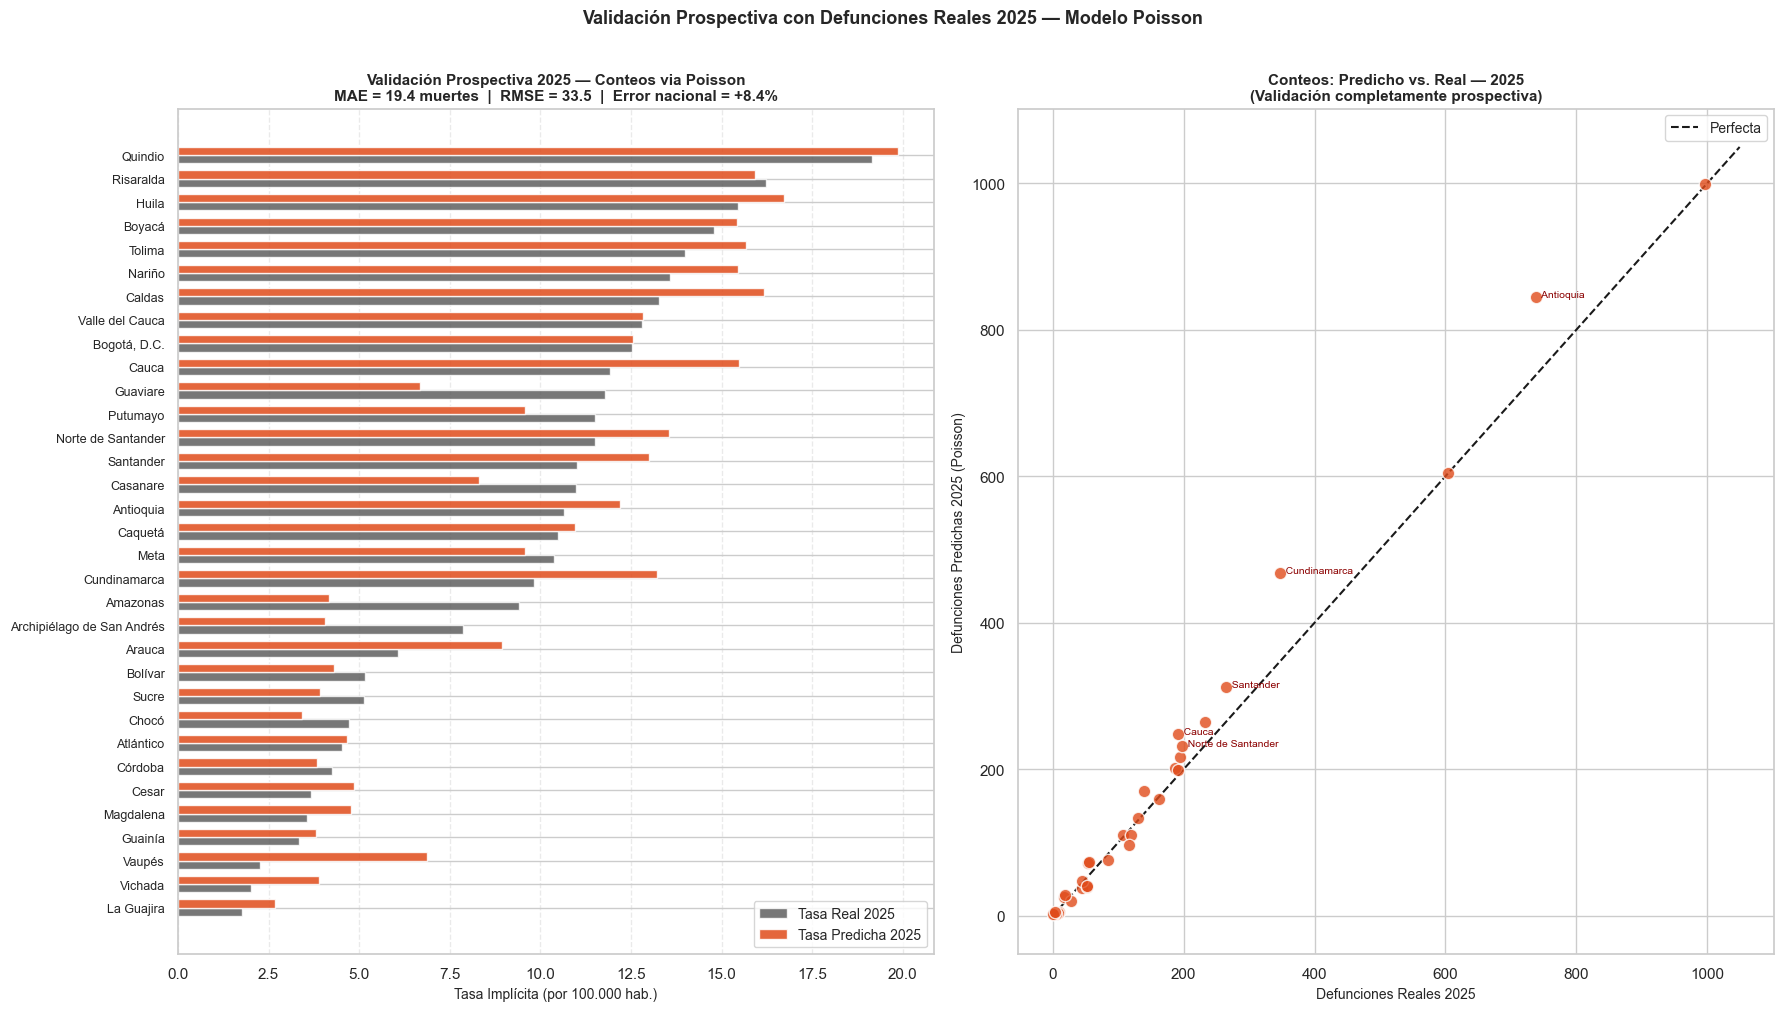


── Mejor ajuste (error < 10%) ──
   departamento  muertes_2025  conteo_predicho_2025  error_pct
        Quindio           107            110.900002        3.7
      Risaralda           163            159.800003        1.9
          Huila           187            202.399994        8.2
         Boyacá           191            199.000000        4.2
Valle del Cauca           604            604.200012        0.0
   Bogotá, D.C.           996            999.500000        0.3
        Caquetá            45             47.000000        4.5
           Meta           120            110.699997        7.7
      Atlántico           130            133.699997        2.8
        Córdoba            85             76.800003        9.7

── Mayor desfase (error > 30%) ──
              departamento  muertes_2025  conteo_predicho_2025  error_pct
                  Guaviare            10              5.700000       43.4
              Cundinamarca           348            467.399994       34.3
                

In [32]:
df_plot = df_comp.dropna(subset=['tasa_real_2025']).sort_values('tasa_real_2025')
y_pos   = np.arange(len(df_plot))
height  = 0.35

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# ── Barras comparativas (tasa implícita) ──────────────────────────────────────
ax1 = axes[0]
ax1.barh(y_pos - height/2, df_plot['tasa_real_2025'],     height,
         label='Tasa Real 2025',     color='#555555', alpha=0.8)
ax1.barh(y_pos + height/2, df_plot['tasa_predicha_2025'], height,
         label='Tasa Predicha 2025', color='#e04b1a', alpha=0.85)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(df_plot['departamento'], fontsize=9)
ax1.set_xlabel('Tasa Implícita (por 100.000 hab.)', fontsize=10)
ax1.set_title(f'Validación Prospectiva 2025 — Conteos via Poisson\n'
              f'MAE = {mae_2025:.1f} muertes  |  RMSE = {rmse_2025:.1f}  |  Error nacional = {error_nacional:+.1f}%',
              fontsize=11, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(axis='x', linestyle='--', alpha=0.4)

# ── Scatter conteos predichos vs reales ──────────────────────────────────────
ax2 = axes[1]
ax2.scatter(df_comp['muertes_2025'], df_comp['conteo_predicho_2025'],
            s=80, color='#e04b1a', edgecolors='white', alpha=0.8, zorder=3)
lim_c = max(df_comp[['muertes_2025','conteo_predicho_2025']].max()) * 1.05
ax2.plot([0, lim_c], [0, lim_c], 'k--', lw=1.5, label='Perfecta')

for _, r in df_comp.nlargest(5, 'error_abs_cnt').iterrows():
    ax2.annotate(f"  {r['departamento']}",
                 xy=(r['muertes_2025'], r['conteo_predicho_2025']),
                 fontsize=7.5, color='darkred')

ax2.set_xlabel('Defunciones Reales 2025', fontsize=10)
ax2.set_ylabel('Defunciones Predichas 2025 (Poisson)', fontsize=10)
ax2.set_title('Conteos: Predicho vs. Real — 2025\n(Validación completamente prospectiva)',
              fontsize=11, fontweight='bold')
ax2.legend(fontsize=10)

plt.suptitle('Validación Prospectiva con Defunciones Reales 2025 — Modelo Poisson',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\n── Mejor ajuste (error < 10%) ──')
print(df_comp[df_comp['error_pct'] < 10][
    ['departamento','muertes_2025','conteo_predicho_2025','error_pct']].round(1).to_string(index=False))
print('\n── Mayor desfase (error > 30%) ──')
print(df_comp[df_comp['error_pct'] > 30][
    ['departamento','muertes_2025','conteo_predicho_2025','error_pct']].round(1).to_string(index=False))


### Interpretación de la Validación 2025

**Comparación con modelo v1 y BYM:**
- Modelo v1 (ratio_adj gaussiano): error nacional = −16.6% (subestimación sistemática)
- Modelo BYM (referencia bayesiana espacial): error nacional = −3.4%
- Modelo v2 Poisson: ver celda anterior — la distribución Poisson debería reducir significativamente el sesgo sistemático al no pasar por la estimación intermedia de tasa ajustada.

**Departamentos con alto ajuste (error < 10%):** Son los de conteos estadísticamente estables (≥ 100 muertes/año). El modelo captura correctamente su posición estructural en el eje andino de riesgo.

**Departamentos con mayor desfase (error > 30%):** Corresponden sistemáticamente a territorios de baja demografía (Vaupés, Guaviare, Amazonas: 1–10 muertes/año). Una variación de 1–2 defunciones altera la tasa en ±5–10 por 100.000, lo que excede la capacidad de cualquier modelo de tendencias. Es ruido Poisson irreducible — ver análisis del techo de ruido en la sección 2.

**`año_relativo = 17`**: un año fuera del rango de entrenamiento (máximo = 16). XGBoost extrapola el último nodo hoja en tendencia, lo que es una limitación conocida — las predicciones usan el valor más cercano del árbol.


In [36]:
import os

# Crear directorio si no existe
os.makedirs('Datos/prediction/xgboost', exist_ok=True)

# Seleccionar solo las columnas necesarias y renombrarlas para Streamlit
df_export = df_2025[['departamento', 'muertes_2025', 'conteo_predicho_2025']].copy()
df_export = df_export.rename(columns={
    'muertes_2025': 'muertes_real',
    'conteo_predicho_2025': 'muertes_xgb'
})

# Redondear predicciones de XGBoost y convertir a número entero
df_export['muertes_xgb'] = df_export['muertes_xgb'].round().astype(int)

# Guardar predicciones de 2025
df_export.to_csv('Datos/prediction/xgboost/predicciones_xgboost_2025.csv', index=False)
print("Predicciones 2025 guardadas exitosamente en: Datos/prediction/xgboost/predicciones_xgboost_2025.csv")

Predicciones 2025 guardadas exitosamente en: Datos/prediction/xgboost/predicciones_xgboost_2025.csv
